In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
# Parameters
train_dir = '/content/drive/MyDrive/Hands40/train'
val_dir   = '/content/drive/MyDrive/Hands40/val'
test_dir  = '/content/drive/MyDrive/Hands40/test'

num_classes = 40
batch_size = 32
image_size = 299  # ✅ Required input size for InceptionV3
epochs = 50
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# Transforms
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
# Datasets and loaders
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [ ]:
# Inception model
model = models.inception_v3(pretrained=True, aux_logits=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 190MB/s] 


In [ ]:
# Training and evaluation
def train(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        outputs, aux_outputs = model(x)  # ← Two outputs from Inception
        loss1 = criterion(outputs, y)
        loss2 = criterion(aux_outputs, y)
        loss = loss1 + 0.4 * loss2  # Combine main + aux loss (0.4 is default weight)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += outputs.argmax(1).eq(y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    preds, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            correct += out.argmax(1).eq(y).sum().item()
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(y.cpu().numpy())
            total += y.size(0)
    return total_loss / total, correct / total, preds, labels


In [ ]:
# Training loop
for epoch in range(epochs):
    train_loss, train_acc = train(model, train_loader)
    val_loss, val_acc, _, _ = evaluate(model, val_loader)
    scheduler.step()
    print(f"Epoch {epoch+1}/{epochs} - Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Val Loss: {val_loss:.4f}")

Epoch 1/50 - Train Acc: 0.0709, Val Acc: 0.1447, Val Loss: 3.3762
Epoch 2/50 - Train Acc: 0.1797, Val Acc: 0.2642, Val Loss: 2.8985
Epoch 3/50 - Train Acc: 0.3007, Val Acc: 0.4717, Val Loss: 2.3058
Epoch 4/50 - Train Acc: 0.4413, Val Acc: 0.5849, Val Loss: 1.8443
Epoch 5/50 - Train Acc: 0.5562, Val Acc: 0.6981, Val Loss: 1.5512
Epoch 6/50 - Train Acc: 0.6504, Val Acc: 0.7610, Val Loss: 1.2416
Epoch 7/50 - Train Acc: 0.7152, Val Acc: 0.8113, Val Loss: 1.0019
Epoch 8/50 - Train Acc: 0.7677, Val Acc: 0.8679, Val Loss: 0.6718
Epoch 9/50 - Train Acc: 0.8081, Val Acc: 0.9057, Val Loss: 0.5854
Epoch 10/50 - Train Acc: 0.8399, Val Acc: 0.9119, Val Loss: 0.4510
Epoch 11/50 - Train Acc: 0.8545, Val Acc: 0.9434, Val Loss: 0.4014
Epoch 12/50 - Train Acc: 0.8631, Val Acc: 0.9371, Val Loss: 0.3661
Epoch 13/50 - Train Acc: 0.8973, Val Acc: 0.9371, Val Loss: 0.3139
Epoch 14/50 - Train Acc: 0.8863, Val Acc: 0.9623, Val Loss: 0.2457
Epoch 15/50 - Train Acc: 0.9132, Val Acc: 0.9560, Val Loss: 0.2806
Epoc

In [ ]:
# Final test evaluation
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader)
print(f"\n✅ Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")



✅ Test Accuracy: 0.9864, Test Loss: 0.0682


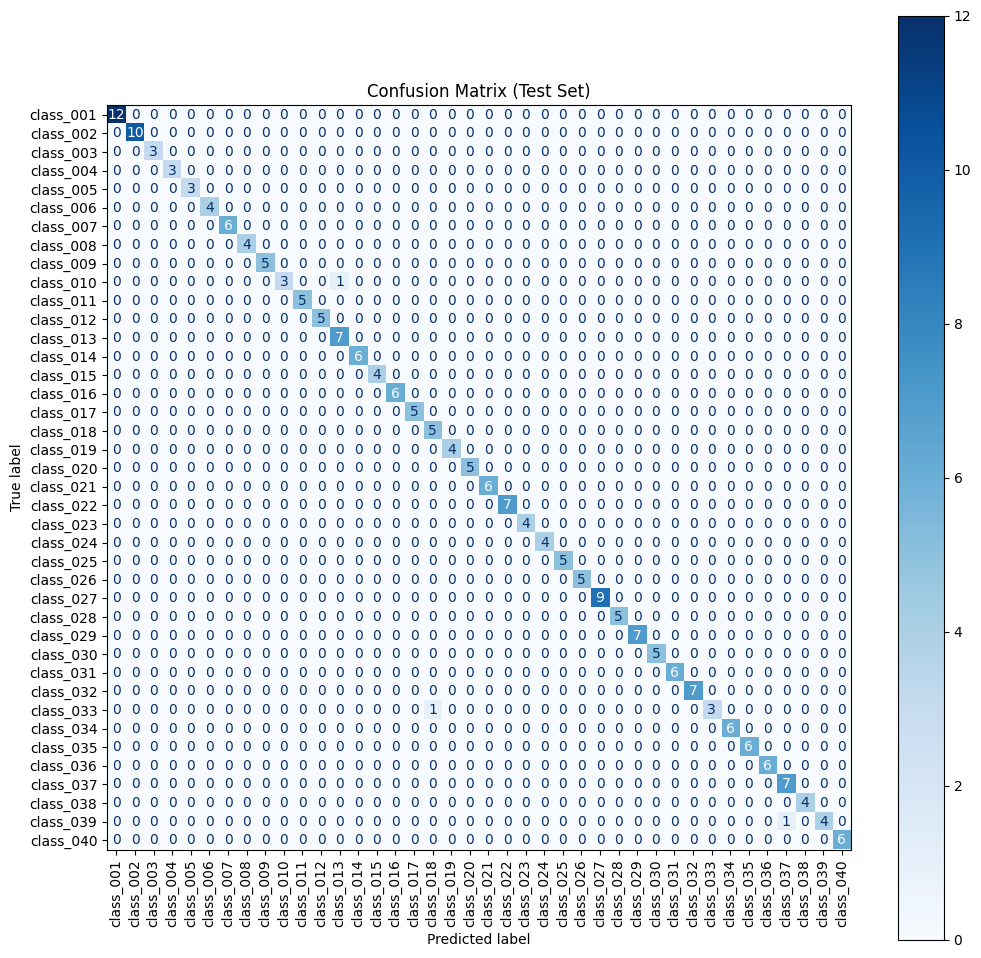

In [ ]:
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_dataset.classes)
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, xticks_rotation=90, cmap='Blues')
plt.title("Confusion Matrix (Test Set)")
plt.show()